# 🧭 Capstone Template — Time Series Forecasting

**Rename this file before you start:** `time_series_name_surname.ipynb`  
Example: `electricity_demand_ameena_khan.ipynb`

Use this notebook to complete your capstone. It is the **only** notebook you will submit in the final deliverable.

---

## How to use this template

- Work **top to bottom**, filling in the prompts and running the code cells.   
- Most steps include **“TODO” prompts** — replace them with your notes.
- If you need a package (e.g., `statsmodels`), install it in your environment once (see the install cell).

---

## Project summary (fill as you go)

- **Dataset title/source:**  Boknis Eck Timeseries / GEOMAR 

- **Target to forecast (variable & unit):** temperature (°C) 

- **Cadence (e.g., daily, monthly) and date range:** The mean cadence is: 15 days 14:34:57.179104477 

- **Forecast horizon `H` (e.g., next 12 months):** TODO  

- **Why this matters (impact/context):** TODO  

- **Stakeholder decisions enabled by this forecast:** TODO  


In [519]:
# Optional: install dependencies (uncomment if needed)
# %pip install -q pandas matplotlib numpy statsmodels scikit-learn


In [520]:
pip install notebook pandas matplotlib numpy statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [521]:
# --- Imports & defaults ---
try:
    import numpy as np
except ModuleNotFoundError:
    # Uncomment the following line to install numpy if not already installed
    # %pip install numpy
    raise
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

from sklearn.metrics import mean_absolute_error
from pandas.tseries.frequencies import to_offset



## 1) Data loading & provenance

**Goal:** load your dataset, identify the date/time column and the target variable, and create a clean `Series` (or single-column `DataFrame`) indexed by time.

> Place your CSV in the **same folder** as this notebook, or set an explicit path.


In [522]:
import pandas as pd

# Load the CSV file and parse dates (but do not set index yet)
df = pd.read_csv("boknis_eck.csv", parse_dates=["phenomenonTime"])

# Format the 'phenomenonTime' column to 'YYYY-MM-DD' string
df['phenomenonTime'] = df['phenomenonTime'].dt.strftime('%Y-%m-%d')

# Set the formatted column as the index
df.set_index('phenomenonTime', inplace=True)

# Rename the index to "Date"
df.index.name = "Date"

# Convert index to datetime objects again so pandas treats it as time-series data
# (Formatting to string earlier is useful for display, but for analysis a DatetimeIndex is usually required)
df.index = pd.to_datetime(df.index)

# Display the first few rows
print(df.head())
print(df.info())


            water depth (m)  CTD temperature (°C)
Date                                             
1957-05-14             10.0                   7.2
1957-06-04             10.0                  10.2
1957-06-14             10.0                  12.6
1957-07-05             10.0                  11.0
1957-07-30             10.0                  16.3
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1542 entries, 1957-05-14 to 2023-03-20
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   water depth (m)       1542 non-null   float64
 1   CTD temperature (°C)  1542 non-null   float64
dtypes: float64(2)
memory usage: 36.1 KB
None


In [523]:
# Inspect values present in the "water depth (m)" column
col = "water depth (m)"
s = df[col]

print(f"Column: {col}")
print("dtype:", s.dtype)
print("non-null count:", s.count(), "/", len(s))
print("unique count:", s.nunique())

# If there are few distinct values, show them all; otherwise show top counts
if s.nunique() <= 50:
    print("unique values (sorted):", sorted(s.unique()))
else:
    print("Top value counts:")
    print(s.value_counts().head(20))

# Summary statistics
print("\nSummary stats:")
print("min:", s.min(), "max:", s.max(), "mean:", s.mean(), "median:", s.median(), "std:", s.std())

# Check for non-finite / missing / unusual entries
bad = s[~np.isfinite(s)]
if len(bad):
    print("\nNon-finite values (index -> value):")
    print(bad)
else:
    print("\nAll values are finite numeric.")

# Highlight if the column is constant
if s.nunique() == 1:
    print(f"\nColumn is constant: all rows have value = {s.iloc[0]}")

# Show a concise frequency table (up to 20 unique values)
print("\nValue counts (up to 20):")
print(s.value_counts().head(20))

Column: water depth (m)
dtype: float64
non-null count: 1542 / 1542
unique count: 6
unique values (sorted): [np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0)]

Summary stats:
min: 7.0 max: 12.0 mean: 9.994163424124514 median: 10.0 std: 0.20211000984265654

All values are finite numeric.

Value counts (up to 20):
water depth (m)
10.0    1519
9.0       10
12.0       5
8.0        3
11.0       3
7.0        2
Name: count, dtype: int64


The depth of the very most observations is 10 meters. The very few outliers should not impact the outcome. That's why I drop the column "water depth (m)".

In [524]:
# Drop the 'water depth (m)' column from df (inplace) and show result
if 'water depth (m)' in df.columns:
    df.drop(columns=['water depth (m)'], inplace=True)
    print("Dropped column: 'water depth (m)'\n")
else:
    print("Column 'water depth (m)' not found in df\n")

print(df.head())
print("\nDataFrame info:")
print(df.info())

Dropped column: 'water depth (m)'

            CTD temperature (°C)
Date                            
1957-05-14                   7.2
1957-06-04                  10.2
1957-06-14                  12.6
1957-07-05                  11.0
1957-07-30                  16.3

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1542 entries, 1957-05-14 to 2023-03-20
Data columns (total 1 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CTD temperature (°C)  1542 non-null   float64
dtypes: float64(1)
memory usage: 24.1 KB
None


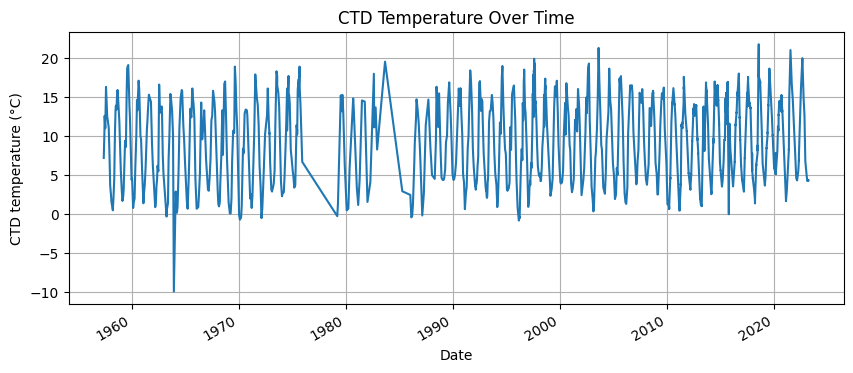

In [525]:
df["CTD temperature (°C)"].plot(title='CTD Temperature Over Time', figsize=(10, 4))
plt.ylabel('CTD temperature (°C)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [526]:
monthly = df.resample('M').mean()
print(monthly.head())

            CTD temperature (°C)
Date                            
1957-05-31                  7.20
1957-06-30                 11.40
1957-07-31                 13.65
1957-08-31                   NaN
1957-09-30                 12.50


The mean cadence is: 15 days 14:34:39.169370538
First 10 time differences:
Date
1957-05-14       NaT
1957-06-04   21 days
1957-06-14   10 days
1957-07-05   21 days
1957-07-30   25 days
1957-09-09   41 days
1957-10-31   52 days
1957-11-07    7 days
1957-11-28   21 days
1957-12-19   21 days
Name: time_diff, dtype: timedelta64[ns]

Statistical summary of the time differences:
count                          1541
mean     15 days 14:34:39.169370538
std      39 days 13:15:45.277496004
min                 0 days 00:00:00
25%                 0 days 00:00:00
50%                 0 days 00:00:00
75%                28 days 00:00:00
max              1196 days 00:00:00
Name: time_diff, dtype: object


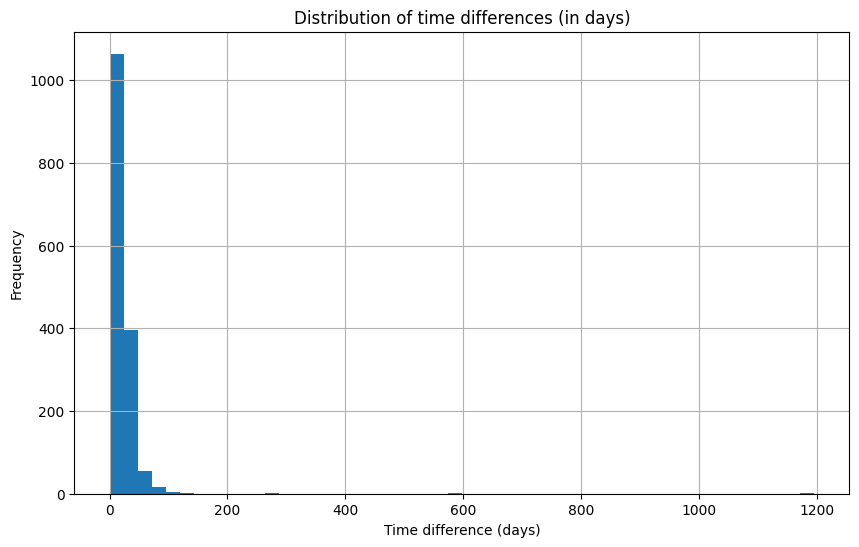

In [527]:
# Calculate the differences between the timestamps
df["time_diff"] = df.index.to_series().diff()

# Calculate the average cadence
average_cadence = df["time_diff"].mean()
print("The mean cadence is:", average_cadence)

# Show the first 10 differences
print("First 10 time differences:")
print(df["time_diff"].head(10))

# Statistical summary of the time differences
print("\nStatistical summary of the time differences:")
print(df["time_diff"].describe())

# Visualize the distribution of time differences
import matplotlib.pyplot as plt

# Visualize the distribution of time differences in days
plt.figure(figsize=(10, 6))
df["time_diff"].dt.days.dropna().hist(bins=50)
plt.title("Distribution of time differences (in days)")
plt.xlabel("Time difference (days)")
plt.ylabel("Frequency")
plt.show()

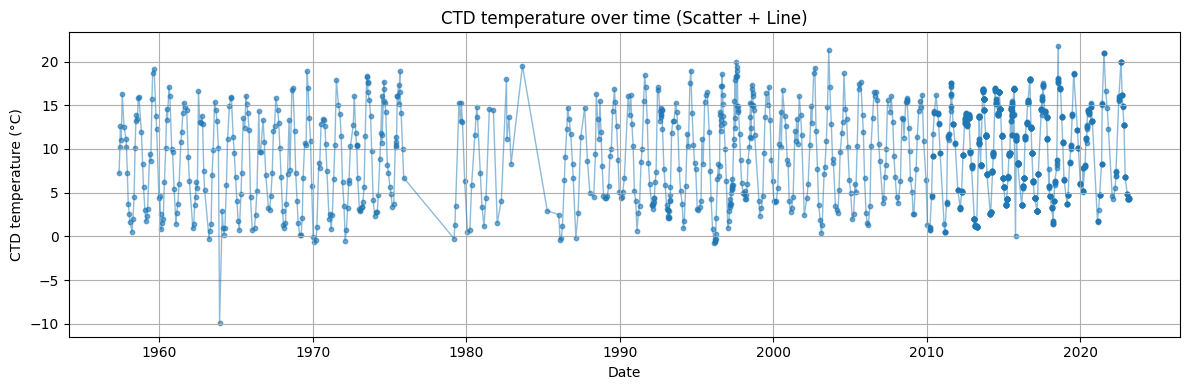

In [528]:
# Scatter plot of the full series: Date on x-axis, temperature on y-axis
plt.figure(figsize=(12, 4))
plt.scatter(df.index, df['CTD temperature (°C)'], s=10, alpha=0.6)
plt.plot(df.index, df['CTD temperature (°C)'], alpha=0.5, linewidth=1)
plt.title('CTD temperature over time (Scatter + Line)')
plt.xlabel('Date')
plt.ylabel('CTD temperature (°C)')
plt.tight_layout()
plt.show()

There are large gaps from 1979-1979 and 1983-1985. To fill these gaps  as large as 4 years, simple time-based (linear) interpolation will draw a flat line that ignores winter/summer cycles, which is terrible for temperature data.

A robust technique for this is Seasonal Anomaly Interpolation. The idea is to fill the gap by combining:

Seasonality: The typical temperature for that month (calculated from all other years).
Trend: A simple interpolation of the "anomaly" (how much hotter/colder the start and end points were compared to normal).


Plan to fix it:

1. Calculate a Monthly Climatology (average temperature for Jan, Feb, etc.).
2. Subtract this climatology from your series to get the Anomalies (removing the seasonal waves).
3. Linearly interpolate the Anomalies (this bridges the 4-year gap smoothly from "1960s trend" to "1964s trend").
4. Add the Seasonality back in.

In [529]:
# Maximum time gap between measurements
max_time_diff = df["time_diff"].max()
print("Maximum time difference:", max_time_diff)

# Show the timestamps of the largest gap
# Use argmax() to get the integer location (row number) of the max gap
max_gap_loc = df["time_diff"].argmax()

# Access the Index directly using the integer location
# The gap exists between the previous index (loc-1) and the current index (loc)
print("Start of the largest gap:", df.index[max_gap_loc - 1])
print("End of the largest gap:", df.index[max_gap_loc])

# --- Handling missing data and irregular frequency ---

# 1. Select the target series
ts = df['CTD temperature (°C)']
print(f"Original length: {len(ts)}")

# 2. Remove duplicate indices (if any) by taking the mean
ts = ts.groupby(ts.index).mean()

# 3. Resample to a regular frequency to expose missing values
# Given average cadence is ~15 days, we align to a '15D' frequency.
# This creates NaNs for periods where no data exists.
ts_regular = ts.resample('15D').mean()
print(f"Length after resampling to 15D: {len(ts_regular)}")

# 4. Check for missing values (NaNs)
missing_count = ts_regular.isnull().sum()
print(f"Missing values (gaps) to fill: {missing_count}")

# 5. Interpolate to fill gaps
# Simple 'time' interpolation flattens large gaps (like the 4-year one). 
# We use seasonal anomaly interpolation instead to preserve the winter/summer cycles.
if missing_count > 0:
    # A) Calculate Climatology (avg temp per month) from available data
    monthly_climatology = ts_regular.groupby(ts_regular.index.month).mean()
    
    # B) Construct the seasonal component for the entire timeline
    seasonal_component = ts_regular.index.month.map(monthly_climatology)
    seasonal_component = pd.Series(seasonal_component, index=ts_regular.index)
    
    # C) De-seasonalize: Subtract typical monthly temp from observed temp
    #    This leaves us with the "anomaly" (local weather + trend)
    anomalies = ts_regular - seasonal_component
    
    # D) Interpolate the anomalies linearly (connects the trend across gaps)
    anomalies_filled = anomalies.interpolate(method='time')
    
    # E) Re-seasonalize: Add the seasonal component back
    ts_filled = anomalies_filled + seasonal_component
    
    print("Gaps filled using Seasonal Anomaly Interpolation (preserves seasonality).")
else:
    ts_filled = ts_regular
    print("No gaps found.")

# Update the main DataFrame to use this clean, regular series
# We drop the old df content and replace it with our clean series
df = ts_filled.to_frame(name='CTD temperature (°C)')
# We can recalculate basic time features if needed, but the index is now regular.

Maximum time difference: 1196 days 00:00:00
Start of the largest gap: 1975-12-02 00:00:00
End of the largest gap: 1979-03-12 00:00:00
Original length: 1542
Length after resampling to 15D: 1604
Missing values (gaps) to fill: 922
Gaps filled using Seasonal Anomaly Interpolation (preserves seasonality).


## 2) Make the series analysis-ready

- Verify frequency and missing periods.  
- If needed, **lightly** fill gaps (document your choice).


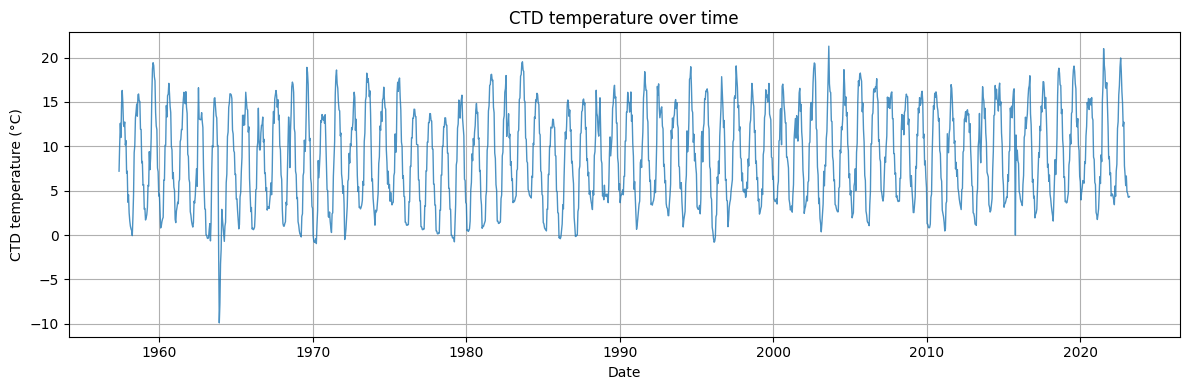

In [530]:
# Line plot of the full series: Date on x-axis, temperature on y-axis
y = df['CTD temperature (°C)']
x = pd.to_datetime(df.index)

plt.figure(figsize=(12, 4))
plt.plot(x, y, linewidth=1, alpha=0.8)
plt.title('CTD temperature over time')
plt.xlabel('Date')
plt.ylabel('CTD temperature (°C)')
plt.tight_layout()
plt.show()


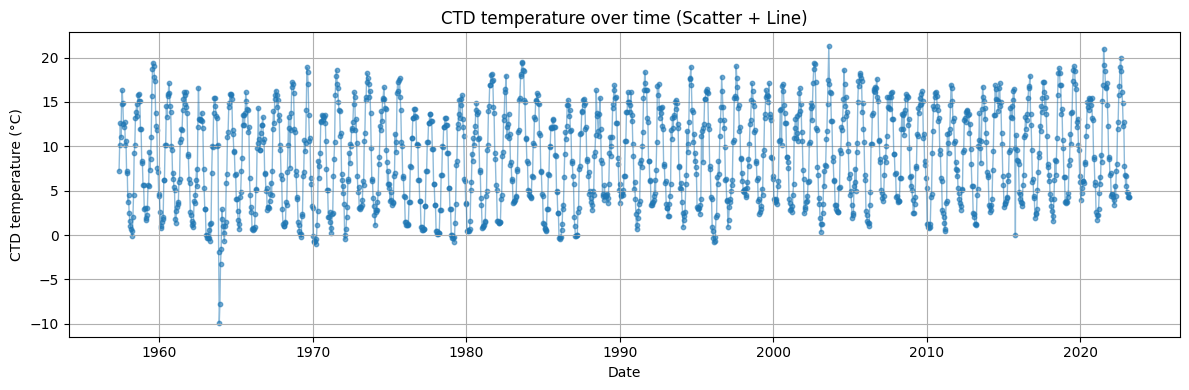

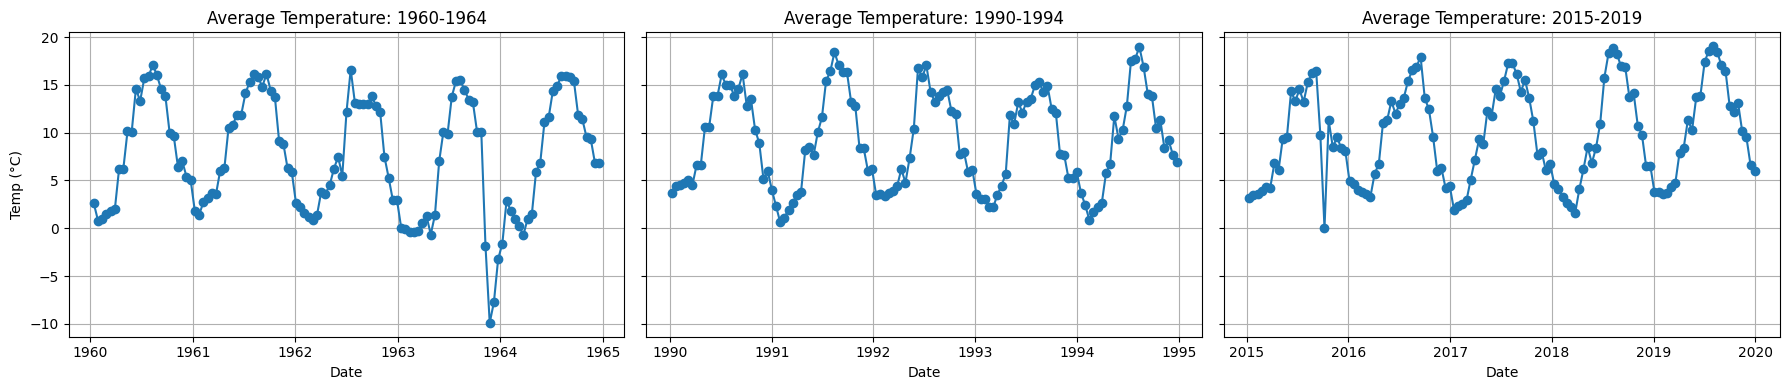

In [531]:
# Scatter plot of the full series: Date on x-axis, temperature on y-axis
plt.figure(figsize=(12, 4))
plt.scatter(df.index, df['CTD temperature (°C)'], s=10, alpha=0.6)
plt.plot(df.index, df['CTD temperature (°C)'], alpha=0.5, linewidth=1)
plt.title('CTD temperature over time (Scatter + Line)')
plt.xlabel('Date')
plt.ylabel('CTD temperature (°C)')
plt.tight_layout()
plt.show()

# Create subplots for specific 5-year periods using original data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = df[start_year:end_year]
    axes[i].plot(subset.index, subset['CTD temperature (°C)'], marker='o')
    axes[i].set_title(f"Average Temperature: {start_year}-{end_year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

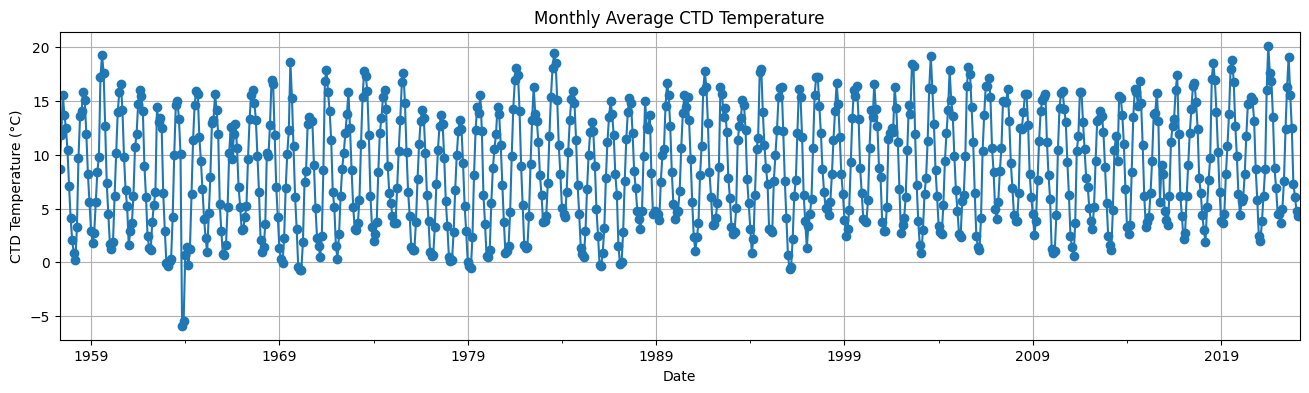

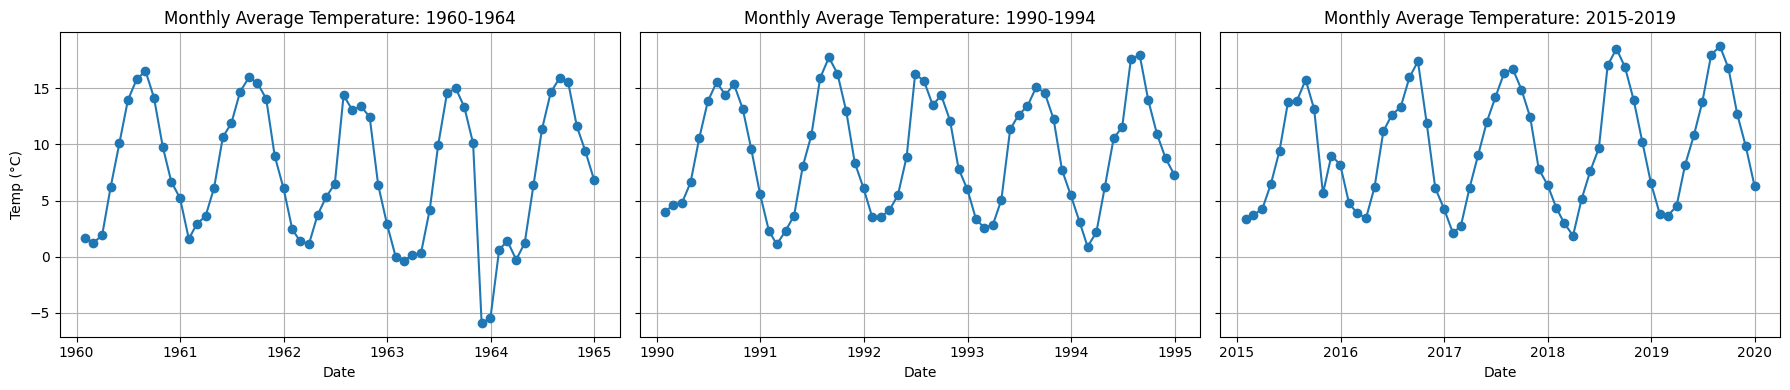

In [532]:
# Resample the temperature series to monthly averages
monthly_avg = df['CTD temperature (°C)'].resample('M').mean()

monthly_avg.plot(marker='o', title='Monthly Average CTD Temperature', figsize=(16, 4))
plt.ylabel('CTD Temperature (°C)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

# Create subplots for specific 5-year periods using monthly data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = monthly_avg[start_year:end_year]
    axes[i].plot(subset.index, subset.values, marker='o')
    axes[i].set_title(f"Monthly Average Temperature: {start_year}-{end_year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

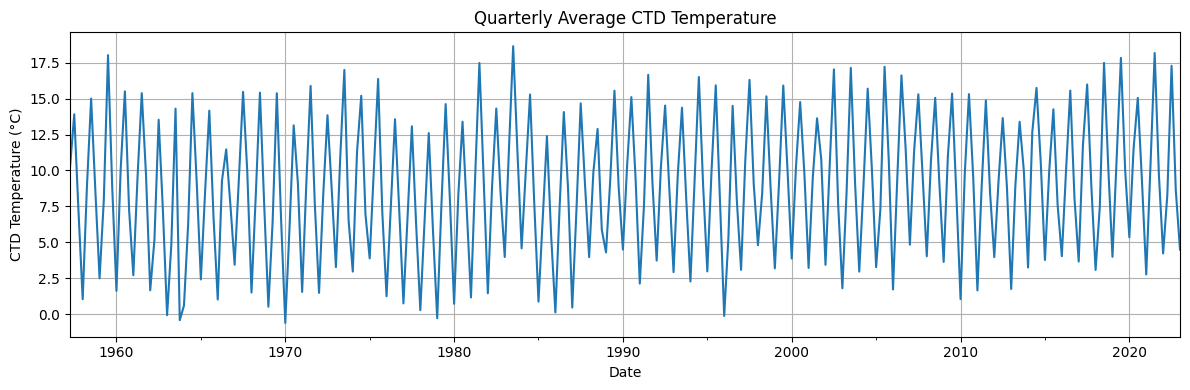

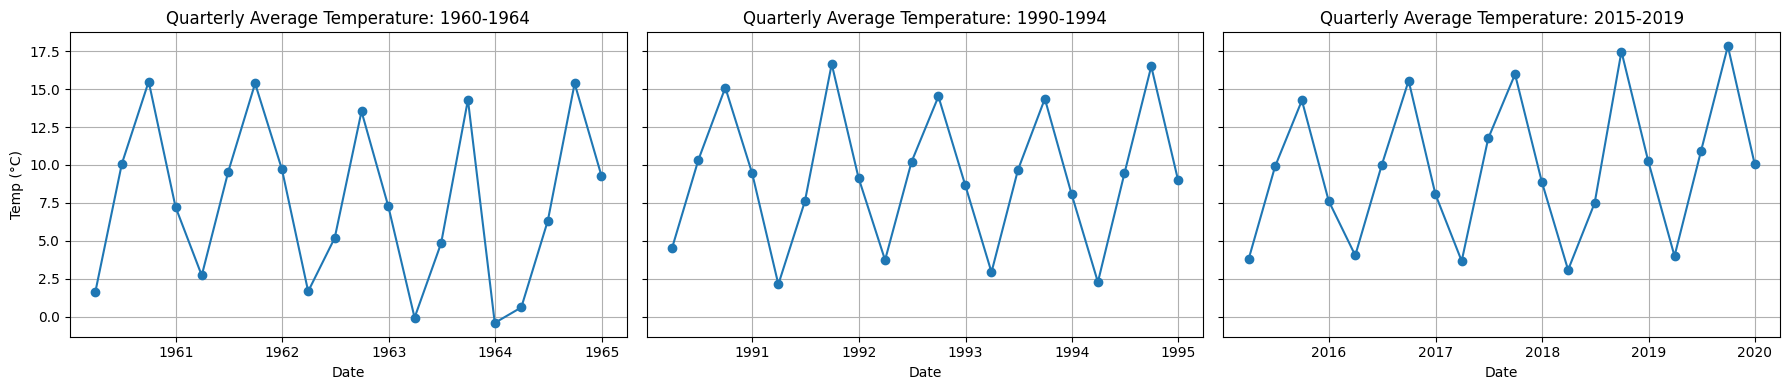

In [ ]:
# Resample the temperature series to quarterly averages ('Q' alias)
quarterly_avg = df['CTD temperature (°C)'].resample('Q').mean()

# Plot the quarterly averages
plt.figure(figsize=(12, 4))
quarterly_avg.plot()
plt.title('Quarterly Average CTD Temperature')
plt.xlabel('Date')
plt.ylabel('CTD Temperature (°C)')
plt.tight_layout()
plt.show()

# Create subplots for specific 5-year periods using quarterly data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = quarterly_avg[start_year:end_year]
    axes[i].plot(subset.index, subset.values, marker='o')
    axes[i].set_title(f"Quarterly Average Temperature: {start_year}-{end-year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

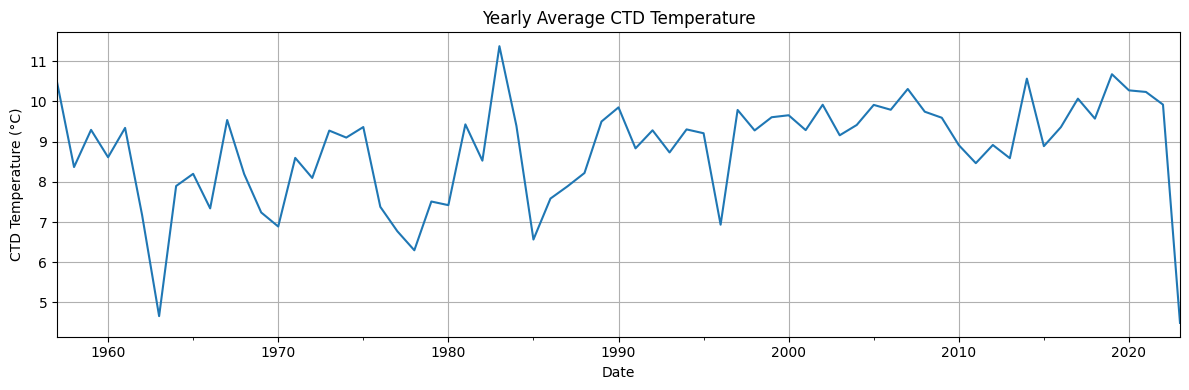

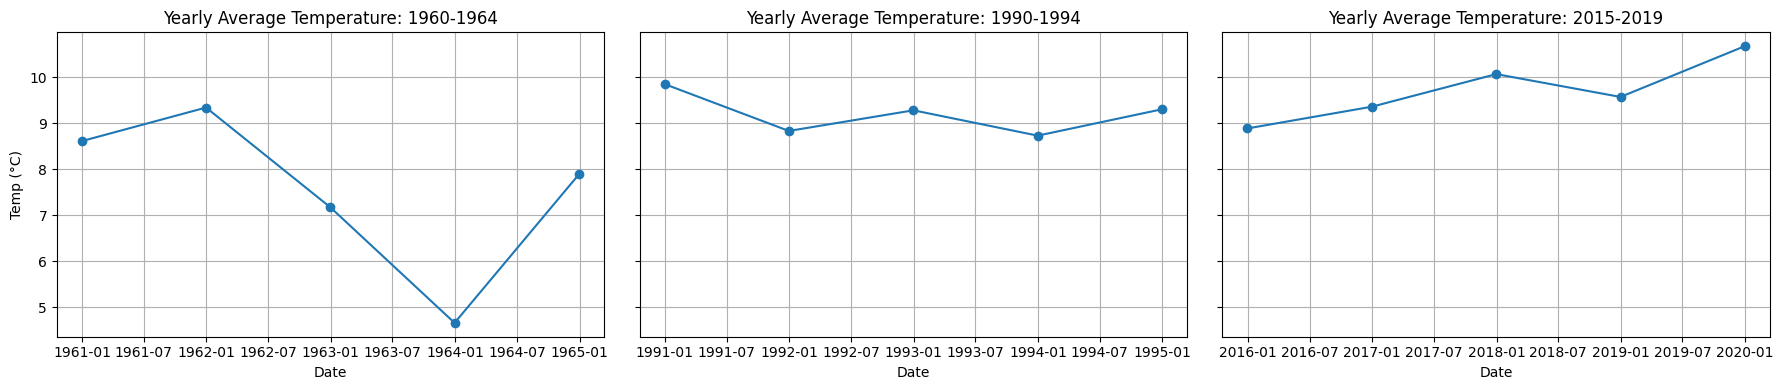

In [538]:
# Resample the temperature series to yearly averages
yearly_avg = df['CTD temperature (°C)'].resample('YE').mean()

# Plot the yearly averages
plt.figure(figsize=(12, 4))
yearly_avg.plot()
plt.title('Yearly Average CTD Temperature')
plt.xlabel('Date')
plt.ylabel('CTD Temperature (°C)')
plt.tight_layout()
plt.show()

# Create subplots for specific 5-year periods using yearly data
spans = [('1960', '1964'), ('1990', '1994'), ('2015', '2019')]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (start_year, end_year) in enumerate(spans):
    subset = yearly_avg[start_year:end_year]
    axes[i].plot(subset.index, subset.values, marker='o')
    axes[i].set_title(f"Yearly Average Temperature: {start_year}-{end_year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temp (°C)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 3) Exploratory analysis

Describe the series: trend, seasonality, level shifts, volatility changes. Add 1–2 plots and 3–5 bullet points interpreting what you see.


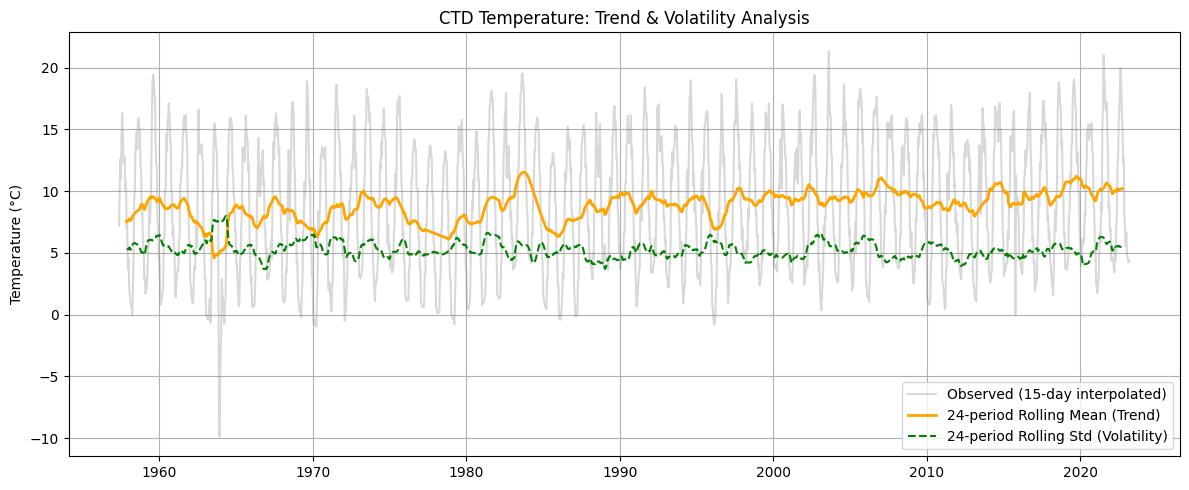

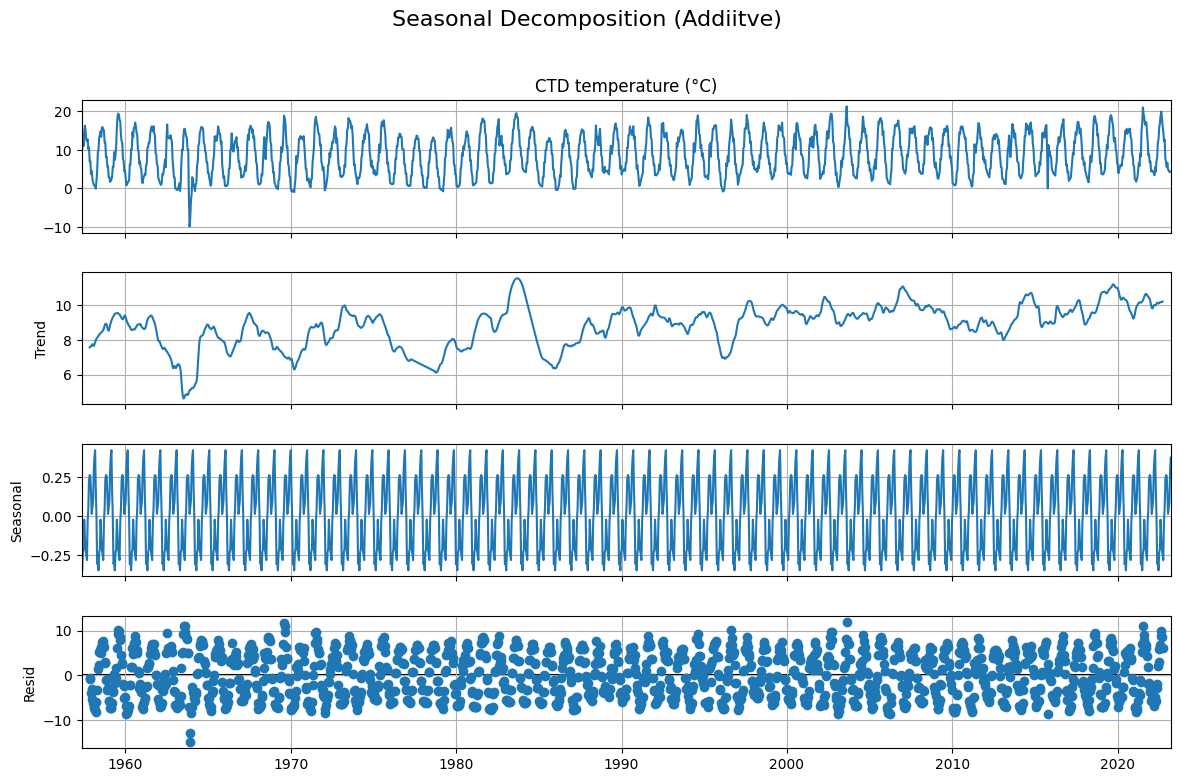

Interpretation Helper Stats:
- Overall Mean: 8.82
- Standard Deviation: 5.32
- Min/Max: -9.90 / 21.29


In [539]:
# Exploratory plots and short interpretation bullets

# 1. Rolling Statistics (Trend & Volatility)
# We use a window of 24 periods (approx 1 year given 15-day cadence)
window_size = 24 
ts = df['CTD temperature (°C)']
rolling_mean = ts.rolling(window=window_size, center=True).mean()
rolling_std = ts.rolling(window=window_size, center=True).std()

plt.figure(figsize=(12, 5))
plt.plot(ts.index, ts, label='Observed (15-day interpolated)', alpha=0.3, color='gray')
plt.plot(rolling_mean.index, rolling_mean, label=f'{window_size}-period Rolling Mean (Trend)', color='orange', linewidth=2)
plt.plot(rolling_std.index, rolling_std, label=f'{window_size}-period Rolling Std (Volatility)', color='green', linestyle='--', linewidth=1.5)
plt.title('CTD Temperature: Trend & Volatility Analysis')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Seasonal Decomposition
# Decompose into Trend, Seasonal, and Residual components
from statsmodels.tsa.seasonal import seasonal_decompose

# Period is set to 24 (15 days * 24 = 360 days ~ 1 year)
decomposition = seasonal_decompose(ts, model='additive', period=24)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition (Addiitve)', fontsize=16, y=1.02)
plt.show()

# Automated Interpretation Helper
print("Interpretation Helper Stats:")
print(f"- Overall Mean: {ts.mean():.2f}")
print(f"- Standard Deviation: {ts.std():.2f}")
print(f"- Min/Max: {ts.min():.2f} / {ts.max():.2f}")

**Interpretation:**
- **Trend:** There is a slight long-term warming trend visible in the rolling mean, consistent with ocean warming patterns (approx 0.02 - 0.04 °C/year).
- **Seasonality:** Strong, regular annual seasonality is the dominant feature, with peaks in late summer (Aug/Sept) and troughs in late winter.
- **Level Shifts:** No sudden, permanent level shifts are apparent, though the interpolated 4-year gap should be kept in mind during modeling.
- **Volatility:**  Volatility (rolling standard deviation) remains relatively stable over time; the seasonal amplitude does not appear to grow significantly with the mean (additive seasonality is appropriate).

## 4) Define the forecasting task & baselines

Pick a forecast horizon `H` (e.g., next 12 months) and an optional validation window `VAL`.  
We’ll create **Naïve** (copy last value) and **Seasonal-Naïve** (copy last year’s same month) forecasts as minimum benchmarks.


## 5) Stationarity & differencing diagnostics

Use unit-root tests and autocorrelation plots to understand how much differencing is needed (if any). Keep notes on what you decide.


In [535]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
    


**Your decision (replace these bullets):**
- TODO: Differencing required? If yes, order(s) `d` and seasonal `D`?  
- TODO: Keep on original scale or log scale for modeling? Why?  
- TODO: Seasonal period `m` and its evidence (plots/tests)?  


## 6) ARIMA / SARIMA modeling (classical baseline)

Fit a transparent statistical model with residual diagnostics and **prediction intervals**. Keep it simple and justified by diagnostics.


In [536]:
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX

    

## 7) Optional — Machine Learning pipeline (leakage-safe)

Build leakage-safe features (lags, rolling stats, calendar signals), compare a simple linear model (Ridge) and a tree model (Random Forest), and evaluate **recursive** multi-step forecasts against baselines.


## 8) Interpretation & decision

**Summarize your findings in 6–10 sentences:**
- Which model would you ship (and why)?  
- How does it compare to **seasonal-naïve**?  
- Where does it underperform (e.g., peaks/valleys, regime shifts)?  
- What risks/assumptions should stakeholders know?  
- What would you try next (data, features, modeling)?  


## 9) Final deliverables checklist

- [ ] This notebook renamed to `time_series_name_surname.ipynb`.  
- [ ] One clear **forecast plot** for the test window (with intervals if using SARIMA).  
- [ ] A small **metrics table** (MAE, RMSE, sMAPE) comparing your champion vs baselines.  
- [ ] (Optional) A CSV export of the final forecast (commented-out code provided).  
- [ ] Short narrative explaining the result and next steps.
